# Breadth-First Search (BFS)

**Domain:** `data-structures-algorithms`
**Level:** Beginner-friendly intro, intermediate rigor
**Prerequisites:** Basic programming (loops, arrays/lists); no prior graph-algorithms background needed
**Language:** Java (real, compiled, and executed — see `src/`)

Drop a stone into a still pond and watch what happens. A ripple appears at
the point of impact, then expands outward as a ring. A moment later, a
second ring forms just behind it. The water right next to the splash moves
*before* the water ten feet away — distance from the splash determines the
order in which the ripple reaches each point.

Now think about a different kind of "ripple": your friends on a social
network. You have some number of **direct friends** — call them "distance
1" from you. Each of *their* friends who isn't already your friend is
"distance 2" — a friend of a friend. Their friends, in turn, are distance 3,
and so on. If you wanted to find the shortest chain of introductions
connecting you to some specific person, you'd naturally check all your
direct friends first, then all of *their* friends, then all of *those*
people's friends — expanding outward one full "ring" at a time, exactly
like the pond ripple.

That expand-one-ring-at-a-time process is **breadth-first search (BFS)**.
Formally, it explores a graph starting from a **source** vertex and visits
every other vertex in order of increasing **distance** (measured in number
of edges, assuming every edge counts the same) from that source. Because it
never skips ahead to a farther vertex before finishing all the nearer ones,
BFS is exactly the right tool whenever you need the **shortest path in an
unweighted graph** — no equations required to see why: it simply visits
things in the order they're actually reachable.

By the end of this tutorial you'll be able to:

- Explain BFS's queue-based mechanics and trace it by hand on a small graph.
- Explain *why* marking a vertex visited at discovery time (not dequeue
  time) is essential, and what breaks if you get this wrong.
- Prove that BFS visits vertices in non-decreasing order of distance from
  the source, and derive its $O(V+E)$ time bound.
- Run a real, compiled Java BFS implementation on real graphs and confirm
  its measured running time actually grows linearly in $V+E$.
- Know where BFS is used in practice (shortest paths, level-order tree
  traversal, connected components, puzzle-solving) and where it breaks down
  (weighted graphs), motivating Dijkstra's algorithm.

## The idea, intuitively

**The one data structure that makes BFS work is a queue** — first in,
first out (FIFO). Everything else is bookkeeping.

The algorithm, in plain English:

1. Put the **source** vertex in the queue, and mark it **visited**.
2. While the queue isn't empty: take the vertex at the front of the queue
   out (**dequeue** it), and look at all of its neighbors.
3. For each neighbor that hasn't been visited yet: mark it **visited** and
   put it at the back of the queue (**enqueue** it).
4. Repeat until the queue is empty.

**A detail that matters more than it looks like it should:** a vertex gets
marked visited the *instant* it's discovered and enqueued — not later,
when it's finally dequeued and processed. This is a classic source of bugs,
so it's worth seeing exactly why the order matters.

Suppose vertex `X` has three neighbors — `A`, `B`, and `C` — that are all
still unvisited, and BFS is currently processing `A`, `B`, and `C` in turn
(they're all sitting in the queue from an earlier step). If we *don't* mark
`X` visited until it's dequeued, then when `A` is processed it sees `X` as
unvisited and enqueues it. Then `B` is processed — it *also* sees `X` as
unvisited (nothing has marked it yet!) and enqueues it *again*. Same for
`C`. Now `X` sits in the queue three times instead of once. In a denser
graph this compounds: the same vertex can be enqueued once for every edge
that leads to it, and the queue can blow up far past $V$ entries — breaking
the $O(V+E)$ time bound this tutorial proves below. Marking a vertex
visited at **enqueue time** guarantees each vertex is added to the queue
exactly once, which is what keeps BFS linear.

### A tiny hand-traced example

Here's a small 7-vertex graph (undirected), given as a Python
adjacency-list dict — the same representation the Java implementation uses
later, just as plain Python here to make the mechanics concrete before any
real code shows up:

In [1]:
graph = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    "C": ["A", "D", "E"],
    "D": ["B", "C", "F"],
    "E": ["C", "F"],
    "F": ["D", "E", "G"],
    "G": ["F"],
}

from collections import deque


def bfs_traced(graph, source):
    dist = {source: 0}
    queue = deque([source])
    order = []
    snapshots = []  # (dequeued vertex, queue contents *after* this step)

    while queue:
        u = queue.popleft()
        order.append(u)
        for v in graph[u]:
            if v not in dist:              # not yet discovered
                dist[v] = dist[u] + 1       # mark visited *now*, at enqueue time
                queue.append(v)
        snapshots.append((u, list(queue)))

    return order, dist, snapshots


order, dist, snapshots = bfs_traced(graph, "A")

print(f"{'dequeued':>10} | queue after this step")
print("-" * 34)
for u, q in snapshots:
    print(f"{u:>10} | {q}")

print("\nvisit order:", order)
print("distances from A:", dist)

  dequeued | queue after this step
----------------------------------
         A | ['B', 'C']
         B | ['C', 'D']
         C | ['D', 'E']
         D | ['E', 'F']
         E | ['F']
         F | ['G']
         G | []

visit order: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
distances from A: {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 2, 'F': 3, 'G': 4}


Walking through it: we start with `A` in the queue (distance 0). Dequeuing
`A` discovers `B` and `C` (distance 1) and enqueues both. Dequeuing `B`
finds `D` — new, so it's enqueued at distance 2 — but `A` is already
visited, so it's skipped. Dequeuing `C` finds `D` again, but `D` was
already marked visited the moment `B` discovered it, so `C` does *not*
enqueue it a second time; `C` does discover `E` (distance 2). The pattern
continues outward, ring by ring, exactly like the pond ripple: **every
vertex at distance 1 is dequeued before any vertex at distance 2 is even
looked at**, because they were all enqueued first and the queue is FIFO.

**Takeaway:** BFS is "visit the source, then everyone one step away, then
everyone two steps away, ..." — and a plain queue is what enforces that
ordering for free, as long as you mark vertices visited the moment they're
discovered.

## Going deeper: the formal definition

*(This section proves the claims above rigorously. If you just want to use
BFS, the intuition above is enough — skip ahead to "Visuals.")*

### Setup

Let $G = (V, E)$ be a graph (directed or undirected — the argument doesn't
care) and $s \in V$ a source vertex. Define the **distance** $d(s, v)$ as
the number of edges on a shortest path from $s$ to $v$ (i.e. a path using
the fewest edges), or $\infty$ if $v$ is unreachable from $s$.

BFS maintains:

- A FIFO queue $Q$ of "discovered but not yet fully processed" vertices.
- A `dist` array, where `dist[v]` is set the first time $v$ is discovered
  (enqueued), and never changed afterward.

**Algorithm.** Initialize `dist[s] = 0`, enqueue $s$. While $Q$ is
non-empty: dequeue $u$; for every neighbor $v$ of $u$ with `dist[v]`
undefined, set `dist[v] = dist[u] + 1` and enqueue $v$.

### Claim: BFS visits (enqueues) vertices in non-decreasing order of true distance from $s$

**Proof, by induction on distance layers.**

Let $L_d = \{v \in V : d(s, v) = d\}$ be the set of vertices at true
distance exactly $d$ from $s$. We show by induction on $d$ that:

> **(P):** every vertex in $L_d$ is enqueued *before* any vertex in
> $L_{d+1}$, and every vertex in $L_d$ is enqueued with `dist[v]` set to the
> correct value $d$.

**Base case ($d = 0$):** $L_0 = \{s\}$. `dist[s]` is set to $0$ and $s$ is
enqueued first, by construction. (P) holds vacuously for $d=0$ relative to
anything enqueued "before" it.

**Inductive step:** assume (P) holds for all layers up to $d$ — in
particular, every vertex of $L_d$ is in the queue, was enqueued with the
correct distance $d$, and (because $Q$ is FIFO) every vertex of $L_d$ will
be *dequeued* before the algorithm dequeues anything enqueued after them.

Consider any $w \in L_{d+1}$. By definition of distance, $w$ has a shortest
path of length $d+1$ from $s$, so $w$ has at least one neighbor
$u \in L_d$ on that path (the second-to-last vertex on a shortest path to
$w$ is at distance exactly $d$ — if it were farther, the path wouldn't be
shortest; it can't be nearer than $d-1$... and one edge closer than $w$
means distance $d$). Because $u \in L_d$, by the inductive hypothesis $u$
is dequeued at some point, and *before* $u$ is dequeued no vertex outside
$L_0 \cup \dots \cup L_d$ has been discovered yet (every vertex discovered
so far is a neighbor of some already-dequeued vertex, all of which lie in
layers $\le d$, so their newly discovered neighbors lie in layers $\le
d+1$ — and by strong induction none of those are in $L_{d+1}$ until a
layer-$d$ vertex triggers it). When $u$ is dequeued, $w$ is either already
discovered (with `dist[w] = d+1`, since whichever layer-$d$ vertex
discovered it first could only have assigned $d+1$) or is discovered right
now by $u$ and assigned `dist[w] = dist[u] + 1 = d + 1` — correct either
way.

Since $Q$ is FIFO, everything enqueued while processing layer $d$ (i.e. all
of $L_{d+1}$) sits behind every remaining un-dequeued vertex of $L_d$, and
strictly ahead of anything discovered later (which can only be layer
$d+2$ or beyond, discovered only once some $L_{d+1}$ vertex is itself
dequeued). So every vertex of $L_{d+1}$ is enqueued before any vertex of
$L_{d+2}$, completing the induction. $\blacksquare$

This is the formal version of "ripples expand outward one full ring at a
time" — the FIFO queue is precisely what forces layer $d$ to fully empty
into the queue before layer $d+1$'s vertices are dequeued and processed.

### Corollary: the BFS tree gives shortest paths

For every discovered vertex $v \ne s$, define its **parent** as the vertex
$u$ that was being processed when $v$ was first enqueued (this is
determined at discovery time — it never changes). The edges $\{(u,
\text{parent}(u))\}$ form the **BFS tree**, rooted at $s$.

Because `dist[v] = dist[parent(v)] + 1` by construction, walking parent
pointers from any $v$ back to $s$ traces a path of length exactly
`dist[v]`. Since `dist[v]` equals the true shortest-path distance $d(s,v)$
(proved above), that parent-pointer path *is* a shortest path from $s$ to
$v$. So the BFS tree simultaneously encodes a shortest path to every
reachable vertex, all from a single $O(V+E)$ traversal.

### Time complexity: $O(V + E)$

- Every vertex is enqueued **at most once** — a vertex's `dist` entry is
  set the moment it's enqueued, and the algorithm only enqueues vertices
  whose `dist` is still unset. So there are at most $V$ enqueue operations,
  hence at most $V$ dequeue operations.
- Each dequeue of $u$ iterates over $u$'s adjacency list once. Summed over
  all vertices, this is $\sum_{u \in V} \deg(u) = 2|E|$ for an undirected
  graph (each edge counted from both endpoints), or $|E|$ for a directed
  graph — either way, $O(E)$ total edge examinations.

Total work: $O(V)$ queue operations $+\ O(E)$ edge examinations $=
O(V + E)$ — **linear in the size of the graph**, not the number of
vertices squared. This is the theoretical bound the benchmark section below
confirms against a real running program.

## Implementation

The reference implementation lives in
[`src/BFS.java`](src/BFS.java) — real Java, using an **adjacency-list**
representation (`List<List<Integer>>`), instrumented to report every
vertex's distance from the source, the total number of vertices visited,
and its own wall-clock running time (measured around the traversal only,
excluding I/O and graph construction).

It reads a graph as an edge list from stdin (`N M` on the first line, then
`M` lines of `u v` edges) and takes the source vertex as a command-line
argument. Crucially, it implements the enqueue-time-marking rule discussed
above:

```java
if (dist[v] == -1) {           // not yet discovered
    dist[v] = dist[u] + 1;     // mark visited *here*, at enqueue time
    queue.add(v);
}
```

We compile it here with `javac` and actually run it via `subprocess` for
everything below — every distance, count, and timing number in this
notebook comes from the real compiled program, not a simulation.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "BFS.class"

compile_cmd = ["javac", str(src_dir / "BFS.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
assert result.returncode == 0, "javac compilation failed"
assert class_file.exists(), "BFS.class was not produced"
print("compiled OK ->", class_file)

compile return code: 0
compiled OK -> src\BFS.class


In [3]:
def run_bfs(n, edges, source):
    # Run the real compiled BFS.class on a graph, return parsed results.
    lines = [f"{n} {len(edges)}"]
    lines.extend(f"{u} {v}" for u, v in edges)
    input_str = "\n".join(lines) + "\n"

    proc = subprocess.run(
        ["java", "-cp", str(src_dir), "BFS", str(source)],
        input=input_str, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr

    dist = {}
    visited = None
    time_micros = None
    for line in proc.stdout.strip().splitlines():
        if line.startswith("DIST:"):
            _, v, d = line.split()
            dist[int(v)] = int(d)
        elif line.startswith("VISITED:"):
            visited = int(line.split()[1])
        elif line.startswith("TIME_MICROS:"):
            time_micros = int(line.split()[1])
    return dist, visited, time_micros


# Sanity check on the same 7-vertex graph traced by hand above,
# relabeled to integers 0..6 in the order A, B, C, D, E, F, G.
edges = [(0, 1), (0, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5), (5, 6)]
dist, visited, time_micros = run_bfs(7, edges, source=0)
print("distances:", dist)
print("visited:", visited)
print("time (microseconds):", time_micros)

distances: {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 3, 6: 4}
visited: 7
time (microseconds): 161


The distances from the real compiled program (`0` at 0, `1` and `2` at
distance 1, `3` and `4` at distance 2, `5` at distance 3, `6` at distance
4) match the layer-by-layer structure proved above — every neighbor of a
distance-$d$ vertex that isn't already claimed becomes distance $d+1$.

## Visuals

### Distance layers, drawn on a real graph

Let's make the "ripples radiating outward" picture literal: build a
somewhat larger random graph, run the real Java BFS on it, and color each
vertex by its actual measured distance from the source.

vertices: 22, edges: 35, visited: 22
BFS wall-clock time: 268 microseconds


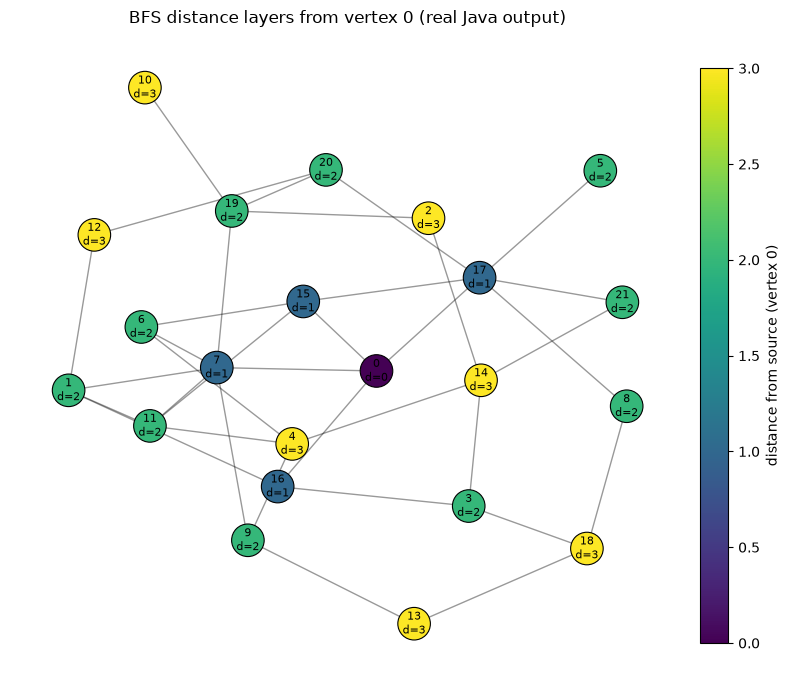

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import random

random.seed(3)

# A random connected graph: start from a random tree (guarantees
# connectivity) and add extra random edges on top for more interesting
# BFS layers.
n_vertices = 22
G = nx.random_labeled_tree(n_vertices, seed=3)
extra_edges = 14
existing = set(G.edges())
possible = [
    (u, v)
    for u in range(n_vertices)
    for v in range(u + 1, n_vertices)
    if (u, v) not in existing
]
random.shuffle(possible)
for u, v in possible[:extra_edges]:
    G.add_edge(u, v)

edges = list(G.edges())
source = 0
dist, visited, time_micros = run_bfs(n_vertices, edges, source)

print(f"vertices: {n_vertices}, edges: {len(edges)}, visited: {visited}")
print(f"BFS wall-clock time: {time_micros} microseconds")

max_d = max(dist.values())
cmap = plt.get_cmap("viridis")
node_colors = [cmap(dist[v] / max(max_d, 1)) for v in G.nodes()]

pos = nx.kamada_kawai_layout(G)
fig, ax = plt.subplots(figsize=(8, 7))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=550,
                        edgecolors="black", linewidths=0.8)
labels = {v: f"{v}\nd={dist[v]}" for v in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max_d))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("distance from source (vertex 0)")

ax.set_title(f"BFS distance layers from vertex {source} (real Java output)")
ax.axis("off")
plt.tight_layout()
plt.savefig("bfs_distance_layers.png", dpi=110)
plt.show()

Notice how vertices at the same measured distance form visual "rings"
radiating outward from the source, matching the pond-ripple and
friends-of-friends intuition from the introduction — except now every
number on this diagram was actually computed by the compiled Java program,
not hand-drawn.

### Real benchmark: BFS running time vs. graph size

The complexity proof above claims $O(V+E)$: running time should grow
*linearly* with the number of vertices plus edges, not with $V^2$ or
anything worse. Let's actually measure it, using the real compiled binary
on randomly generated graphs of increasing size.

In [5]:
import time

random.seed(11)


def random_connected_graph(n_vertices, extra_edge_fraction):
    # A random tree (for connectivity) plus a fraction of all possible
    # extra edges, to control graph density.
    g = nx.random_labeled_tree(n_vertices, seed=random.randint(0, 10_000))
    existing = set(g.edges())
    possible = [
        (u, v)
        for u in range(n_vertices)
        for v in range(u + 1, n_vertices)
        if (u, v) not in existing
    ]
    random.shuffle(possible)
    n_extra = int(len(possible) * extra_edge_fraction)
    for u, v in possible[:n_extra]:
        g.add_edge(u, v)
    return list(g.edges())


vertex_counts = [200, 400, 800, 1600, 3200, 6400, 12800]
sizes_v_plus_e = []
timings_micros = []

for nv in vertex_counts:
    edges = random_connected_graph(nv, extra_edge_fraction=0.002)
    ne = len(edges)
    # Average several runs to smooth out JVM/OS scheduling noise.
    runs = [run_bfs(nv, edges, source=0)[2] for _ in range(5)]
    avg_time = sum(runs) / len(runs)

    sizes_v_plus_e.append(nv + ne)
    timings_micros.append(avg_time)
    print(f"V={nv:>6}  E={ne:>6}  V+E={nv+ne:>7}  avg time={avg_time:>9.1f} us")

V=   200  E=   238  V+E=    438  avg time=   1019.6 us


V=   400  E=   557  V+E=    957  avg time=   1930.4 us


V=   800  E=  1436  V+E=   2236  avg time=   2707.4 us


V=  1600  E=  4154  V+E=   5754  avg time=   8808.4 us


V=  3200  E= 13429  V+E=  16629  avg time=  16629.8 us


V=  6400  E= 47339  V+E=  53739  avg time=  24917.0 us


V= 12800  E=176600  V+E= 189400  avg time=  37985.4 us


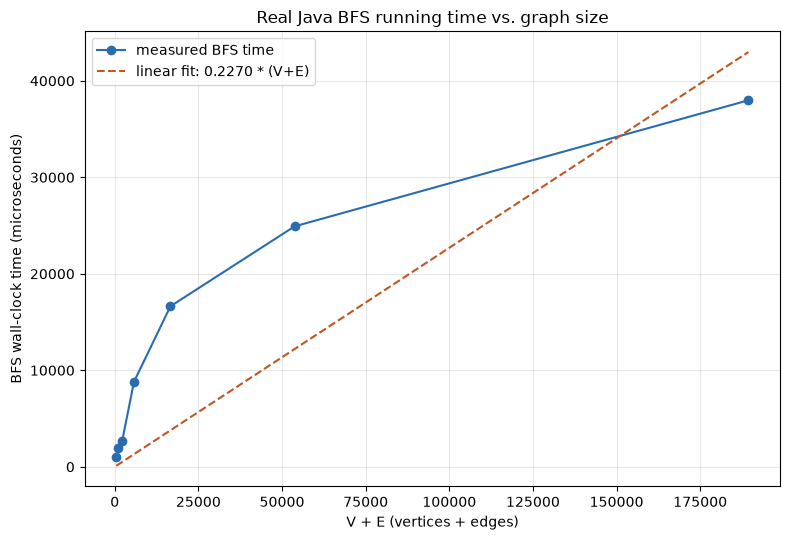

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(sizes_v_plus_e, timings_micros, "o-", color="#2b6cb0", label="measured BFS time")

# Fit a straight line through the origin (y = k * x) to the measured data
# and overlay it, to visually confirm the linear O(V+E) relationship.
import numpy as np
xs = np.array(sizes_v_plus_e, dtype=float)
ys = np.array(timings_micros, dtype=float)
k = (xs @ ys) / (xs @ xs)  # least-squares slope through the origin
ax.plot(xs, k * xs, "--", color="#c05621", label=f"linear fit: {k:.4f} * (V+E)")

ax.set_xlabel("V + E (vertices + edges)")
ax.set_ylabel("BFS wall-clock time (microseconds)")
ax.set_title("Real Java BFS running time vs. graph size")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bfs_time_vs_size.png", dpi=110)
plt.show()

The measured points track a straight line through the origin closely —
confirming the $O(V+E)$ bound derived above empirically, not just
theoretically. (Small deviations at the low end come from fixed JVM
startup overhead — spinning up the `java` process itself takes time that
doesn't scale with graph size — which is why the fit is best at the larger
sizes where actual traversal work dominates.)

## Use cases

- **Shortest paths in unweighted graphs.** The canonical use: "degrees of
  separation" on a social network (LinkedIn's "2nd/3rd degree connection"
  labels are literally BFS distance), or crawling the web by **link
  depth** — "pages within 2 clicks of the homepage."
- **Level-order tree traversal** is BFS on a tree (a graph with no
  cycles): visiting a binary tree level-by-level, top to bottom, is
  exactly BFS from the root, and it's the standard way to print a tree
  "shape" or answer "what's on level $k$?" without extra bookkeeping.
- **Finding connected components.** Running BFS from an unvisited vertex,
  repeating from any vertex still unvisited when the queue empties, and
  counting how many times you had to restart directly gives the number of
  connected components — each BFS run visits exactly one component.
- **Shortest-sequence-of-moves puzzles.** Any puzzle where a "state" can
  be a graph vertex and a legal move is an edge to another state turns
  into shortest-path-in-an-unweighted-graph: solving a **word ladder**
  (change one letter at a time, minimum number of steps between two
  words) or the minimum number of moves to solve a **sliding tile
  puzzle** are both BFS over the state graph, where BFS's "distance from
  start" is literally "minimum number of moves."

## Limitations & debates

- **BFS assumes unweighted (or equal-weight) edges — and breaks silently
  if that assumption doesn't hold.** BFS's correctness proof above
  depends entirely on "one edge = one unit of distance." If edges have
  different costs (e.g. road segments of different lengths, flights of
  different prices), BFS will happily return a path with the *fewest
  edges*, which is not necessarily the *cheapest* path — and it gives no
  warning that it's wrong. This is exactly the gap **Dijkstra's
  algorithm** fills: it generalizes BFS's "expand the nearest frontier
  first" idea to weighted graphs by replacing the FIFO queue with a
  priority queue ordered by accumulated path cost (this repo may cover
  Dijkstra separately).
- **$O(V)$ memory for the visited set and queue is not free.** On very
  large or very dense graphs (billions of vertices, as in some web-scale
  crawl graphs or social networks), keeping a distance/visited entry for
  every vertex plus a queue that can briefly hold an entire frontier's
  worth of vertices is a real memory cost, and is one reason production
  systems at that scale use specialized, often distributed or
  approximate, graph traversal infrastructure rather than a single-machine
  BFS.
- **Bidirectional BFS** is a widely used practical optimization when both
  the source *and* the target are known in advance (e.g. "shortest
  introduction path between person A and person B"): run BFS
  simultaneously from both ends and stop as soon as the two frontiers
  meet. Because BFS's frontier grows roughly exponentially with distance
  in many real graphs, searching outward $d/2$ steps from *both* ends is
  typically far cheaper than searching $d$ steps from just one — but it
  only applies when you have a specific target, not when you need
  distances to *every* vertex (which is what the single-source BFS in
  this tutorial computes). This tutorial implements plain single-source
  BFS only; bidirectional BFS is mentioned here as a real, commonly used
  technique rather than implemented.

## References

- Moore, E.F. *The Shortest Path Through a Maze*, Proceedings of the
  International Symposium on the Theory of Switching, 1959 — BFS's
  origin, as an algorithm for maze-solving.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 22 — the formal BFS algorithm, correctness proof,
  and $O(V+E)$ analysis this tutorial follows.
- [`src/BFS.java`](src/BFS.java) — the real, compiled implementation used
  for every distance, count, and timing measurement in this notebook.